# WASTE CLASSIFICATION — COMPLETE COLAB MANUAL
## 05 — Ifaza M.D.U — IT25102486
### Pixel Normalization

**IMPORTANT:** This version is intentionally code-heavy. Each numbered cell below is intended to be copied into Google Colab and run in sequence. Do not skip validation cells.

## A. ONE-TIME COLAB SETUP
### 00. Set member identity — run this before the common cells

In [ ]:
MEMBER_NAME = "Ifaza M.D.U"
IT_NUMBER = "IT25102486"
TASK = "Pixel Normalization"
print(MEMBER_NAME, IT_NUMBER, TASK)

Ifaza M.D.U IT25102486 Pixel Normalization


### 01. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


### 02. Install/check packages

In [ ]:
!pip -q install pandas pillow matplotlib numpy imagehash
import os, shutil, hashlib, json, csv, math
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = False
print("Packages imported.")

Packages imported.


### 03. Define project folders

In [ ]:
PROJECT = Path("/content/drive/MyDrive/Waste_Classification")
RAW_DIR = PROJECT / "data" / "raw"
PROCESSED_DIR = PROJECT / "data" / "processed"
RESULTS_DIR = PROJECT / "results"
REPORT_DIR = PROJECT / "audit_reports"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"

for p in [PROCESSED_DIR, RESULTS_DIR, REPORT_DIR, EDA_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg",".jpeg",".png",".webp",".bmp",".gif",".tif",".tiff"}
print("PROJECT =", PROJECT)
print("RAW_DIR =", RAW_DIR)
assert PROJECT.exists(), "Waste_Classification folder was not found."
assert RAW_DIR.exists(), "data/raw was not found. Check your Drive folder."

PROJECT = /content/drive/MyDrive/Waste_Classification
RAW_DIR = /content/drive/MyDrive/Waste_Classification/data/raw


### 04. List project folders

In [ ]:
for p in [PROJECT, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, REPORT_DIR]:
    print("\n", p)
    if p.exists():
        for child in list(p.iterdir())[:20]:
            print("  ", child.name)


 /content/drive/MyDrive/Waste_Classification
   data
   results
   audit_reports
   notebooks
   code
   README.md
   .gitignore
   .git_backup
   .git

 /content/drive/MyDrive/Waste_Classification/data/raw
   Hazardous
   Non-Recyclable
   Organic
   Recyclable
   .complete

 /content/drive/MyDrive/Waste_Classification/data/processed
   stage1_cleaning
   stage2_deduplicated
   stage2_visual_deduplicated
   stage3_labels
   stage4_standardized
   stage5_normalized

 /content/drive/MyDrive/Waste_Classification/results
   eda_visualizations
   outputs
   member2_visual_review (2)
   member2_visual_review (1)
   member2_visual_review
   member2_visual_review_final
   logs

 /content/drive/MyDrive/Waste_Classification/audit_reports
   member1_image_audit.csv
   member1_image_warnings.csv
   member3_label_warnings.csv
   member4_standardization_manifest.csv


### 05. Create a run log

In [ ]:
RUN_LOG = OUTPUT_DIR / "preprocessing_run_log.txt"
RUN_LOG.write_text(
    "Waste Classification preprocessing run\n"
    f"Member: {MEMBER_NAME}\n"
    f"IT Number: {IT_NUMBER}\n"
)
print("Run log:", RUN_LOG)

Run log: /content/drive/MyDrive/Waste_Classification/results/outputs/preprocessing_run_log.txt


## B. YOUR COMPLETE ASSIGNED-PREPROCESSING CODE
### 06. Set input stage

In [ ]:
STAGE4 = PROCESSED_DIR / "stage4_standardized"
assert STAGE4.exists(), "Stage 4 is missing."
files = sorted(STAGE4.rglob("*.jpg"))
print("Input images:", len(files))

Input images: 2136


### 07. Install/import PyTorch

In [54]:
import torch
from torchvision import transforms
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


### 08. Define ImageNet normalization

In [ ]:
IMAGE_SIZE = (224,224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)
print("Mean:", IMAGENET_MEAN)
print("Std :", IMAGENET_STD)

Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]


### 09. Test one image before/after normalization

In [ ]:
img=Image.open(files[0]).convert("RGB")
tensor_before=to_tensor(img)
tensor_after=normalize(tensor_before.clone())

print("Image:",files[0].name)
print("Before min/max/mean:",float(tensor_before.min()),float(tensor_before.max()),float(tensor_before.mean()))
print("After min/max/mean:",float(tensor_after.min()),float(tensor_after.max()),float(tensor_after.mean()))
print("Tensor shape:",tensor_after.shape)

Image: 1-s2.0-S0892687521004477-ga1.jpg
Before min/max/mean: 0.0 1.0 0.9037959575653076
After min/max/mean: -2.1179039478302 2.640000104904175 2.0136125087738037
Tensor shape: torch.Size([3, 224, 224])


### 10. Plot normalization EDA

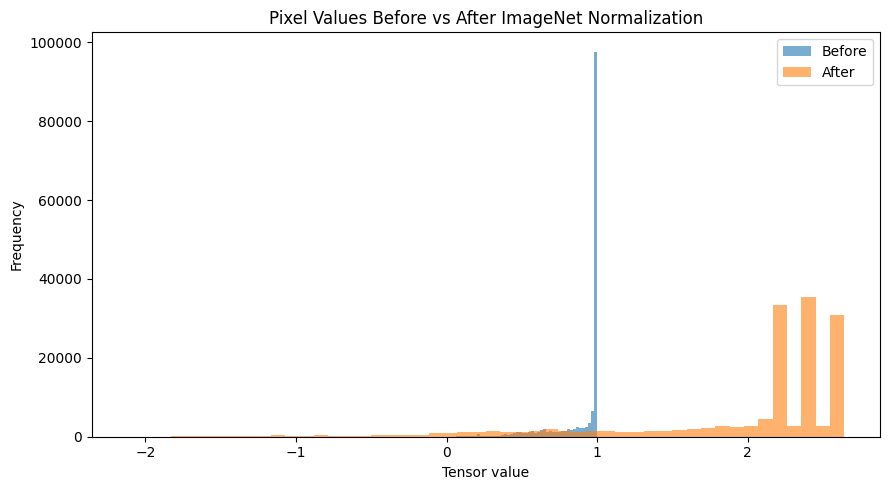

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member5_normalization_histogram.png


In [ ]:
plt.figure(figsize=(9,5))
plt.hist(tensor_before.flatten().numpy(),bins=50,alpha=.6,label="Before")
plt.hist(tensor_after.flatten().numpy(),bins=50,alpha=.6,label="After")
plt.title("Pixel Values Before vs After ImageNet Normalization")
plt.xlabel("Tensor value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
path=EDA_DIR/"member5_normalization_histogram.png"
plt.savefig(path,dpi=200); plt.show()
print("Saved:",path)

### 11. Verify transform on a batch

In [ ]:
sample_files=files[:min(16,len(files))]
batch=torch.stack([normalize(to_tensor(Image.open(p).convert("RGB"))) for p in sample_files])
print("Batch shape:",batch.shape)
print("Batch mean:",float(batch.mean()))
print("Batch std:",float(batch.std()))
assert batch.shape[1:] == (3,224,224)

Batch shape: torch.Size([16, 3, 224, 224])
Batch mean: 0.8236435055732727
Batch std: 1.4713338613510132


### 12. Save exact preprocessing specification

In [ ]:
spec = {
    "resize": [224,224],
    "to_tensor": True,
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
    "note": "Normalization is a model-input transform; do not save normalized values as JPEG."
}
path=OUTPUT_DIR/"member5_normalization_spec.json"
path.write_text(json.dumps(spec,indent=2))
print("Saved:",path)

Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member5_normalization_spec.json


### 13. Create reusable transform code file

In [ ]:
transform_code = """from torchvision import transforms

train_or_eval_normalize = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
"""
path=OUTPUT_DIR/"member5_normalization_transform.py"
path.write_text(transform_code)
print("Saved:",path)

Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member5_normalization_transform.py


### 14. Git save commands

In [60]:
!git -C /content/drive/MyDrive/Waste_Classification status
!git -C /content/drive/MyDrive/Waste_Classification add notebooks results/outputs results/eda_visualizations
!git -C /content/drive/MyDrive/Waste_Classification commit -m "IT25102486 - normalization transform"
# !git -C /content/drive/MyDrive/Waste_Classification push

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a560bd05fa65.(none)')


## C. FINAL CHECKS — RUN THESE AFTER YOUR LAST STAGE CELL
### FINAL CHECK 1 — Count the output images

In [ ]:
# Change this only if your stage output folder has a different name.
STAGE_OUT = {
    "01": PROCESSED_DIR / "stage1_cleaning",
    "02": PROCESSED_DIR / "stage2_deduplicated",
    "03": PROCESSED_DIR / "stage3_labels",
    "04": PROCESSED_DIR / "stage4_standardized",
    "05": PROCESSED_DIR / "stage4_standardized",
    "06": PROCESSED_DIR / "stage4_standardized"
}["05"]

if STAGE_OUT.exists():
    output_images=[p for p in STAGE_OUT.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    print("Output images:",len(output_images))
else:
    print("This stage does not create a new permanent image folder.")

Output images: 2622


### FINAL CHECK 2 — List your output files

In [ ]:
print("Outputs:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

print("\nEDA:")
for p in sorted(EDA_DIR.glob("*")):
    print(" -", p.name)

Outputs:
 - IT25102140_completion_record.json
 - IT25102344_completion_record.json
 - IT25102486_completion_record (1).json
 - IT25102486_completion_record (2).json
 - IT25102486_completion_record (3).json
 - IT25102486_completion_record (4).json
 - IT25102486_completion_record (5).json
 - IT25102486_completion_record.json
 - IT25102510_completion_record.json
 - member1_stage1_manifest.csv
 - member2_cross_class_duplicate_review.csv
 - member2_final_visual_duplicate_review.csv
 - member2_new_visual_duplicate_candidates.csv
 - member2_perceptual_hashes.csv
 - member2_same_class_exact_duplicate_exclusions.csv
 - member2_stage2_final_manifest (1).csv
 - member2_stage2_final_manifest.csv
 - member3_class_mapping.json
 - member3_label_consistency_audit.csv
 - member3_label_validation.csv
 - member4_standardization_manifest.csv
 - member5_TEST_FILE (1).txt
 - member5_TEST_FILE.txt
 - member5_normalization_spec (1).json
 - member5_normalization_spec (2).json
 - member5_normalization_spec (3).

### FINAL CHECK 3 — Save a completion record

In [ ]:
completion = {
    "member": MEMBER_NAME,
    "it_number": IT_NUMBER,
    "task": TASK,
    "status": "COMPLETED",
    "next_step": "Hand off verified output to the next member."
}
completion_path = OUTPUT_DIR / "IT25102486_completion_record.json"
completion_path.write_text(json.dumps(completion, indent=2))
print("Saved:", completion_path)

Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/IT25102486_completion_record.json


### FINAL CHECK 4 — Git status

In [59]:
!git -C /content/drive/MyDrive/Waste_Classification status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)


### FINAL CHECK 5 — What you hand to the next member

In [ ]:
print("""
=======================================================
MEMBER 05 — PIXEL NORMALIZATION HANDOFF SUMMARY
=======================================================
Input Stage  : data/processed/stage4_standardized
Output Stage : data/processed/stage4_standardized (No new image folder saved; transform used at input)
Image Size   : 224 x 224 (RGB)
Normalization: ImageNet Benchmark
  Mean       : [0.485, 0.456, 0.406]
  Std        : [0.229, 0.224, 0.225]
Tensor Shape : (3, 224, 224)

Artifacts Generated:
- Notebook  : notebooks/IT25102486_PixelNormalization.ipynb
- Transform : results/outputs/member5_normalization_transform.py
- Spec JSON : results/outputs/member5_normalization_spec.json
- Histogram : results/eda_visualizations/member5_normalization_histogram.png
- Record    : results/outputs/IT25102486_completion_record.json
=======================================================
""")

In [65]:
# Current Cell 06
STAGE4 = PROCESSED_DIR / "stage4_standardized"
assert STAGE4.exists(), "Stage 4 is missing."
files = sorted(STAGE4.rglob("*.jpg"))
print("Input images:", len(files))

Input images: 2136


In [56]:
# 1. Set your Git identity
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102486@my.sliit.lk"
!git -C /content/drive/MyDrive/Waste_Classification config user.name "Ifaza M.D.U"

# 2. Stage all untracked files
!git -C /content/drive/MyDrive/Waste_Classification add .

# 3. Create the commit
!git -C /content/drive/MyDrive/Waste_Classification commit -m "IT25102486 - normalization transform"

# 4. Check the status to verify success
!git -C /content/drive/MyDrive/Waste_Classification status

error: invalid object 100644 a5d7b84a673458d14d9aab082183a1968c2c7492 for '.git_backup/hooks/applypatch-msg.sample'
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a560bd05fa65.(none)')
On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .git_backup/COMMIT_EDITMSG
	new file:   .git_backup/HEAD
	new file:   .git_backup/ORIG_HEAD
	new file:   .git_backup/ORIG_HEAD (1)
	new file:   .git_backup/ORIG_HEAD (2)
	new file:   .git_backup/config
	new file:   .git_backup/description
	new file:   .git_backup/hooks/applypatch-msg.sample
	new file:   .git_backup/hooks/commit-msg.sample
	new file:   .git_backup/hooks/fsmonitor-watchman.sample
	new file:   .git_backup/hooks/pos

In [63]:
# 1. Set your Git identity
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102486@my.sliit.lk"
!git -C /content/drive/MyDrive/Waste_Classification config user.name "Ifaza Dilshad"

# 2. Link the remote GitHub repository
!git -C /content/drive/MyDrive/Waste_Classification remote remove origin 2>/dev/null || true
!git -C /content/drive/MyDrive/Waste_Classification remote add origin https://github.com/IT25102140/waste-classification-aiml.git

# 3. Ignore .git_backup so it stops causing errors
!echo ".git_backup/" >> /content/drive/MyDrive/Waste_Classification/.gitignore

# 4. Fetch and align with remote main branch
!git -C /content/drive/MyDrive/Waste_Classification fetch origin
!git -C /content/drive/MyDrive/Waste_Classification reset --hard origin/main

# 5. Check status
!git -C /content/drive/MyDrive/Waste_Classification status

remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 79 (delta 32), reused 32 (delta 11), pack-reused 0 (from 0)
Unpacking objects: 100% (79/79), 3.67 MiB | 1.08 MiB/s, done.
From https://github.com/IT25102140/waste-classification-aiml
   e6f5f54..7931ac1  main       -> origin/main
fatal: ambiguous argument 'origin/main': unknown revision or path not in the working tree.
Use '--' to separate paths from revisions, like this:
'git <command> [<revision>...] -- [<file>...]'
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)


In [64]:
# 1. Set Git identity
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102486@my.sliit.lk"
!git -C /content/drive/MyDrive/Waste_Classification config user.name "Ifaza Dilshad"

# 2. Force checkout and track origin/main directly
!git -C /content/drive/MyDrive/Waste_Classification checkout -B main origin/main

# 3. Verify status
!git -C /content/drive/MyDrive/Waste_Classification status

fatal: 'origin/main' is not a commit and a branch 'main' cannot be created from it
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)
